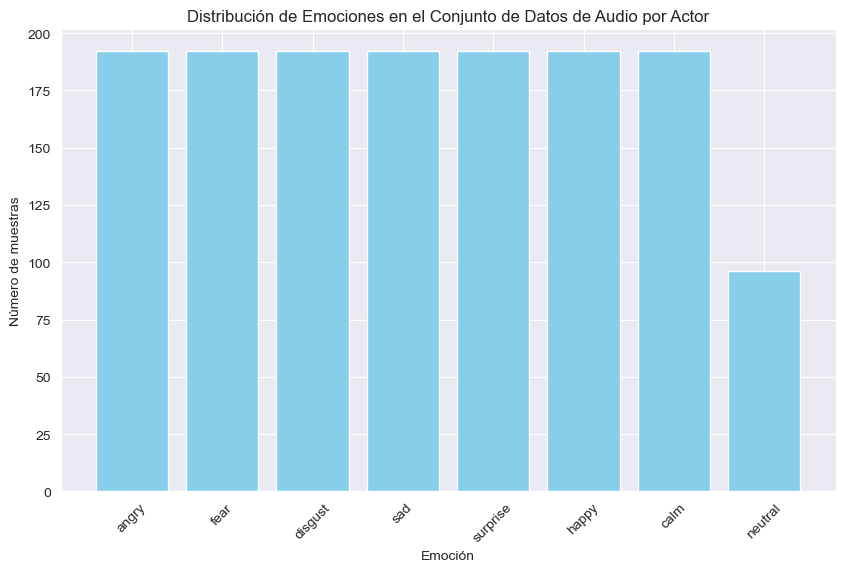

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Definir la ruta de las carpetas de audio
audio_dir = "../data/audio"  # Ruta a la carpeta base con las carpetas de actores
actors = [actor for actor in os.listdir(audio_dir) if not actor.startswith('.')]  # Ignorar carpetas ocultas

# Crear un diccionario para almacenar el conteo de cada emoción por actor
emotion_counts = {}

# Emociones codificadas en los nombres de los archivos (extraídas del formato del nombre)
emotion_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
    '08': 'surprise'
}

# Recorrer cada actor y contar las emociones presentes
for actor in actors:
    actor_folder = os.path.join(audio_dir, actor)
    for audio_file in os.listdir(actor_folder):
        if not audio_file.endswith('.wav'):  # Filtrar archivos que no sean de audio .wav
            continue
        emotion_code = audio_file.split("-")[2]  # Extraer la emoción del nombre del archivo
        emotion = emotion_dict.get(emotion_code, "unknown")  # Mapear el código a la emoción
        if emotion in emotion_counts:
            emotion_counts[emotion] += 1
        else:
            emotion_counts[emotion] = 1

# Crear un DataFrame para visualizar la distribución
df_emotions = pd.DataFrame(list(emotion_counts.items()), columns=["Emoción", "Cantidad"])
df_emotions = df_emotions.sort_values(by="Cantidad", ascending=False)

# Visualizar la distribución
plt.figure(figsize=(10, 6))
plt.bar(df_emotions['Emoción'], df_emotions['Cantidad'], color='skyblue')
plt.xlabel('Emoción')
plt.ylabel('Número de muestras')
plt.title('Distribución de Emociones en el Conjunto de Datos de Audio por Actor')
plt.xticks(rotation=45)
plt.show()


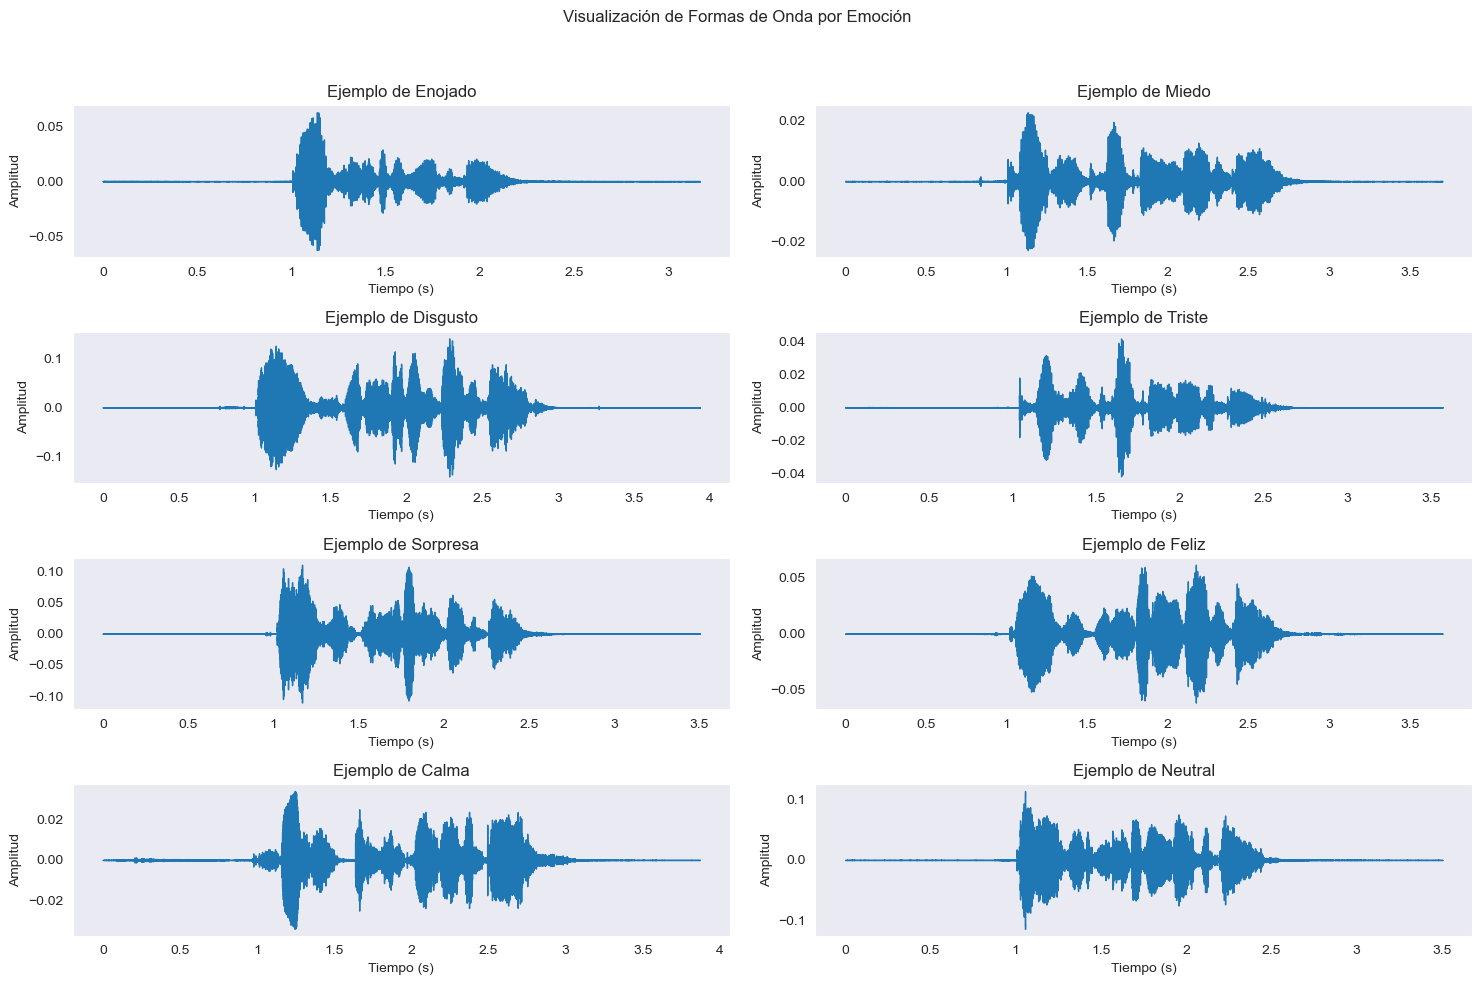

In [8]:
import os
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Directorio del dataset de audio
audio_dir = '../data/audio'  # Ajusta el directorio según la ubicación de tus datos
emotions = ["enojado", "miedo", "disgusto", "triste", "sorpresa", "feliz", "calma", "neutral"]

# Crear la figura para visualizar las formas de onda
plt.figure(figsize=(15, 10))
for i, emotion in enumerate(emotions, 1):
    # Buscar un archivo de ejemplo para cada emoción
    emotion_folder = os.path.join(audio_dir, f'Actor_01')  # Carpeta de un actor específico
    file_name = [f for f in os.listdir(emotion_folder) if f.split('-')[2] == str(i).zfill(2)][0]
    file_path = os.path.join(emotion_folder, file_name)

    # Cargar el archivo de audio y extraer la forma de onda
    y, sr = librosa.load(file_path, sr=None)
    
    # Graficar la forma de onda
    plt.subplot(4, 2, i)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Ejemplo de {emotion.capitalize()}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid()

# Ajustar y mostrar la figura
plt.suptitle("Visualización de Formas de Onda por Emoción")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


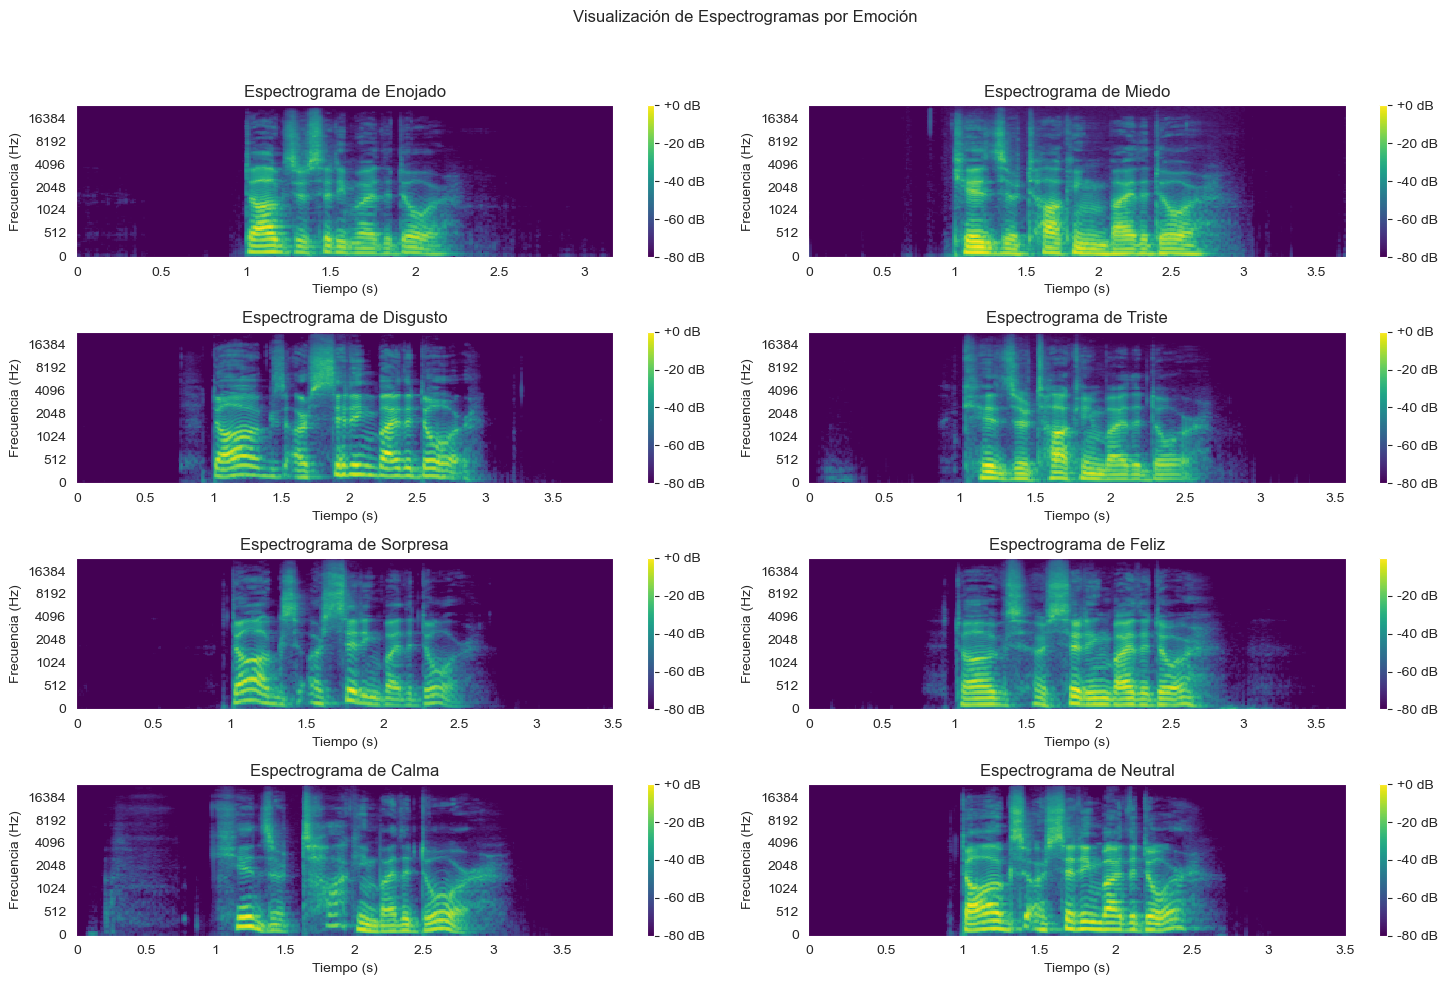

In [10]:
import os
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Directorio del dataset de audio
audio_dir = '../data/audio'  # Ajusta el directorio según la ubicación de tus datos
emotions = ["enojado", "miedo", "disgusto", "triste", "sorpresa", "feliz", "calma", "neutral"]

# Crear la figura para visualizar los espectrogramas
plt.figure(figsize=(15, 10))
for i, emotion in enumerate(emotions, 1):
    # Buscar un archivo de ejemplo para cada emoción
    emotion_folder = os.path.join(audio_dir, 'Actor_01')  # Carpeta de un actor específico
    file_name = [f for f in os.listdir(emotion_folder) if f.split('-')[2] == str(i).zfill(2)][0]
    file_path = os.path.join(emotion_folder, file_name)

    # Cargar el archivo de audio y extraer el espectrograma
    y, sr = librosa.load(file_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)  # Calcular espectrograma
    S_dB = librosa.power_to_db(S, ref=np.max)  # Convertir a escala logarítmica (decibeles)

    # Graficar el espectrograma
    plt.subplot(4, 2, i)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
    plt.title(f"Espectrograma de {emotion.capitalize()}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Frecuencia (Hz)")
    plt.colorbar(format='%+2.0f dB')

# Ajustar y mostrar la figura
plt.suptitle("Visualización de Espectrogramas por Emoción")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
